In [1]:
import pandas as pd
from intcf import CausalForest

seed = 42
covariate_names = [
    'sex', 'race', 'age', 'education', 'smokeintensity',
    'smokeyrs', 'exercise', 'active', 'wt71'
]

In [2]:
nhefs_all = pd.read_csv("nhefs.csv")

restriction_cols = [
    'sex', 'age', 'race', 'wt82', 'ht', 'school', 'alcoholpy', 'smokeintensity'
]
missing = nhefs_all[restriction_cols].isnull().any(axis=1)
nhefs = nhefs_all.loc[~missing]

nhefs.shape

(1566, 64)

In [3]:
treatment = nhefs['qsmk'].to_numpy()
covariates = nhefs[covariate_names].to_numpy()
outcome = nhefs['wt82_71'].to_numpy()

In [4]:
cf = CausalForest(random_state=seed)
cf.fit(X=covariates, T=treatment, y=outcome)
print(f"Predicted average treatment effect: {cf.predict(covariates).mean():.2f}")

Predicted average treatment effect: 3.20


In [5]:
importances = pd.DataFrame({
    "Feature": covariate_names,
    "Heterogeneity score": cf.feature_importances(),
    "Bias score": cf.feature_importances(method='bias')
})
importances['Heterogeneity rank'] = importances['Heterogeneity score'].rank(ascending=False).astype(int)
importances['Bias rank'] = importances['Bias score'].rank(ascending=False).astype(int)
importances['Heterogeneity score (Rank)'] = importances['Heterogeneity score'].combine(importances['Heterogeneity rank'], lambda score, rank: f"{score:.3f} ({rank:d})")
importances['Bias score (Rank)'] = importances['Bias score'].combine(importances['Bias rank'], lambda score, rank: f"{score:.3f} ({rank:d})")
importances.sort_values(by='Heterogeneity score', ascending=False, inplace=True)
print("Feature importance scores:")
importances[['Feature', 'Heterogeneity score (Rank)', 'Bias score (Rank)']]

Feature importance scores:


,Feature,Heterogeneity score (Rank),Bias score (Rank)
8,wt71,0.288 (1),-0.234 (9)
5,smokeyrs,0.175 (2),0.056 (5)
2,age,0.171 (3),0.517 (1)
4,smokeintensity,0.124 (4),0.146 (3)
3,education,0.078 (5),0.089 (4)
7,active,0.061 (6),0.012 (6)
6,exercise,0.053 (7),0.181 (2)
0,sex,0.037 (8),-0.038 (7)
1,race,0.013 (9),-0.164 (8)


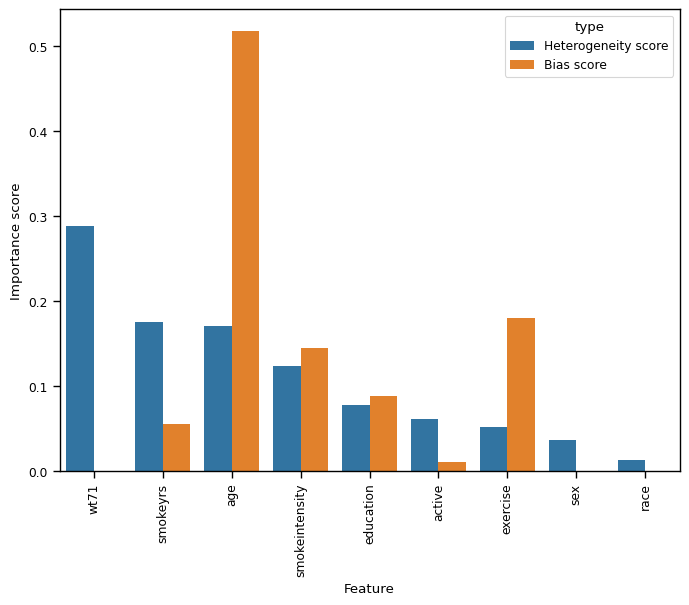

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_context("paper")
plt.figure(figsize=(8, 6))
reshaped = importances.sort_values(by='Heterogeneity score', ascending=False)
reshaped['Bias score'] = reshaped['Bias score'].map(lambda x: pd.NA if x < 0 else x)
reshaped = reshaped.melt(id_vars='Feature', value_vars=['Heterogeneity score', 'Bias score'], value_name='Importance score').rename(columns={'variable': 'type'})
sns.barplot(reshaped, x='Feature', y='Importance score', hue='type')
plt.xticks(rotation=90)
plt.savefig("importance_scores.png", bbox_inches='tight')